# Llama2-style Components in Needle

Group 68
Mentor: Patrick Chen
Mentee:
- Dapeng Gao (dapengg)
- Chenyue Ma (chenyuem)
- Shuaichen Yan (shuaichy)


This notebook walks through four Llama2 components—RMSNorm, RoPE, SwiGLU, and GQA—reimplemented in the Needle transformer.

What’s inside:

- An architecture sketch, then one section per component.
- For each: what it is, why it’s used, how it’s wired, and how it’s tested.
- A brief note on the parity heatmaps plus a closing summary.

Colab workflow: run setup (mount/clone/pip/make), set env vars, then execute the pytest cells for each part.


In [1]:
# Code to set up the assignment
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/
!mkdir -p 10714
%cd /content/drive/MyDrive/10714
!git clone https://github.com/dlsyscourse/hw4_extra.git
%cd /content/drive/MyDrive/10714/hw4_extra

!pip3 install --upgrade --no-deps git+https://github.com/dlsys10714/mugrade.git
!pip3 install pybind11

Mounted at /content/drive
/content/drive/MyDrive
/content/drive/MyDrive/10714
fatal: destination path 'hw4_extra' already exists and is not an empty directory.
/content/drive/MyDrive/10714/hw4_extra
  Cloning https://github.com/dlsys10714/mugrade.git to /tmp/pip-req-build-npdyym4y
  Running command git clone --filter=blob:none --quiet https://github.com/dlsys10714/mugrade.git /tmp/pip-req-build-npdyym4y
  Resolved https://github.com/dlsys10714/mugrade.git to commit ac73f725eb2ce0e2c6a38fa540035ee970b8b873
  Preparing metadata (setup.py) ... done
  Created wheel for mugrade: filename=mugrade-1.3-py3-none-any.whl size=3708 sha256=dc3121b5f171187ce188ee2c84fe5e28ff7794e096a59c8f264c6a6e569abfd8
  Stored in directory: /tmp/pip-ephem-wheel-cache-0ck53x3q/wheels/df/c7/14/2b747145fc762900af3ff05bd0c9192c506e70db3ef3890239
Successfully built mugrade
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 7.6 MB/s eta 0:00:00


In [2]:
!make

CMake Deprecation Warning at CMakeLists.txt:1 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


-- Found pybind11: /usr/local/lib/python3.12/dist-packages/pybind11/include (found version "3.0.1")
-- Found cuda, building cuda backend
Tue Dec  9 21:37:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|

In [3]:
%set_env PYTHONPATH ./python
%set_env NEEDLE_BACKEND nd

env: PYTHONPATH=./python
env: NEEDLE_BACKEND=nd


In [4]:
import sys
sys.path.append('./python')

## Section 1: Llama2 architecture overview

![Llama2 block sketch](llama2.png)

Data path: `Token → Embed → [Block × N] → LM Head`. Each block is pre-norm with two residuals. Order: RMSNorm → Attention (RoPE, optional GQA) → Residual → RMSNorm → SwiGLU FFN → Residual. Embeddings, LM head, masks, and dropout follow the baseline Needle setup. Residual scale stays 1.0; no post-norm.

Why these swaps:
- RMSNorm: cheaper than LayerNorm and stable in pre-norm stacks.
- RoPE: relative position encoding via rotation, better for long text.
- SwiGLU: gated MLP that beats ReLU with tiny extra cost.
- GQA: fewer K/V heads, smaller KV cache and bandwidth.

Extra details: we keep attention scaling, causal masking, and dropout values unchanged so we can compare directly with the baseline. The new pieces slot into the same call sites, so training scripts and configs do not need edits. If you change the number of heads or hidden size, re-run the tests to confirm shapes and norms are still correct. When debugging, print tensor shapes at each step: embed → norm → attention → FFN to spot mismatches. Keep an eye on dtype; run in float32 unless you add mixed precision tests. For clarity in the report, jot down the exact block order and note any hyperparameter tweaks. If you see NaNs, first check eps and the backend setting (`NEEDLE_BACKEND`).

Code map: transformer wiring is in `python/needle/nn/nn_transformer.py`; RMSNorm is in `nn_basic.py`. Tests live in `tests/section2_rmsnorm`, `section3_rope`, `section4_swiglu`, and `section5_gqa`. On Colab CPU, each pytest set finishes in under a minute; GPU is optional. Read the later sections before changing code so you know the expected shapes and tolerances; keep the code and test outputs together when you submit.

Reference: Llama2 from the ground up, a great intro with plain english and trivial terminology: https://cameronrwolfe.substack.com/p/llama-2-from-the-ground-up

## Section 2: RMSNorm

**What** — Root-mean-square normalization with no mean subtraction:

$$
\hat{x} =
rac{x}{\sqrt{	frac{1}{d}\sum_i x_i^2 +
arepsilon}},\quad y = w \odot \hat{x}
$$

Here \(d\) is hidden size, \(
arepsilon\) is under the square root, and \(w\) is a learned scale (no bias).

**Why** — Fewer operations than LayerNorm, less mean drift, and matches Llama2 checkpoints. Stable in deep pre-norm stacks and cheap to compute on CPU/GPU. Works well with residual connections because it keeps mean untouched.

**Implementation**
- Added `RMSNorm` to `nn_basic.py`.
- Swapped LayerNorm1d → RMSNorm in attention and FFN prenorms inside `nn_transformer.py`.
- Kept interface identical to LayerNorm1d so shapes and calls stay the same. Default `eps` 1e-5 but can be passed in. Works for numpy and ND backends. No bias term is used, only scale. Backprop uses the same autograd path as other elementwise ops. You can reuse this module elsewhere in Needle without code changes.

**Tests**
- `python3 -m pytest -l -v -k "test_rmsnorm"`: numpy reference on random shapes and eps. Checks max abs error < 1e-5 and all outputs finite. If it fails, print denominator terms and confirm `eps` is inside the sqrt. Also check that shapes match the input.
- `python3 -m pytest -l -v -k "test_rmsnorm_compare"`: compares with Hugging Face `LlamaRMSNorm` on the same weights/inputs. Catches scale ordering or dtype issues. Both run fast on CPU. Save outputs for grading. When changing eps or dtype, rerun both tests and log max diff. If you see NaNs in bf16/fp16, raise eps slightly.

**Reference**
- Root Mean Square Layer Normalization
https://arxiv.org/abs/1910.07467


In [5]:
!python3 -m pytest -l -v -k "test_rmsnorm"

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/10714/hw4_extra
plugins: langsmith-0.4.55, anyio-4.12.0, typeguard-4.4.4
collected 136 items / 126 deselected / 10 selected                             

tests/test_rmsnorm.py::test_rmsnorm_matches_numpy[cpu] PASSED            [ 10%]
tests/test_rmsnorm.py::test_rmsnorm_matches_numpy[cuda] PASSED           [ 20%]
tests/test_rmsnorm.py::test_rmsnorm_scales_with_weight[cpu] PASSED       [ 30%]
tests/test_rmsnorm.py::test_rmsnorm_scales_with_weight[cuda] PASSED      [ 40%]
tests/test_rmsnorm.py::test_attention_and_transformer_use_rmsnorm[cpu] PASSED [ 50%]
tests/test_rmsnorm.py::test_attention_and_transformer_use_rmsnorm[cuda] PASSED [ 60%]
tests/test_rmsnorm_compare.py::test_rmsnorm_matches_llama_impl[cpu] PASSED [ 70%]
tests/test_rmsnorm_compare.py::test_rmsnorm_matches_lla

In [6]:
!python3 -m pytest -l -v -k "test_rmsnorm_compare"

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/10714/hw4_extra
plugins: langsmith-0.4.55, anyio-4.12.0, typeguard-4.4.4
collected 136 items / 132 deselected / 4 selected                              

tests/test_rmsnorm_compare.py::test_rmsnorm_matches_llama_impl[cpu] PASSED [ 25%]
tests/test_rmsnorm_compare.py::test_rmsnorm_matches_llama_impl[cuda] PASSED [ 50%]
tests/test_rmsnorm_compare.py::test_rmsnorm_forward_latency_small[cpu] PASSED [ 75%]
tests/test_rmsnorm_compare.py::test_rmsnorm_forward_latency_small[cuda] PASSED [100%]

====================== 4 passed, 132 deselected in 14.05s ======================


## Section 3: RoPE

**What** — Rotary Position Embeddings rotate Q/K pairs instead of adding absolute vectors.

$$
	heta_k = 	ext{base}^{-2k/d},\quad
\begin{aligned}
q'_{2k} &= q_{2k}\cos	heta_k - q_{2k+1}\sin	heta_k,\
q'_{2k+1} &= q_{2k}\sin	heta_k + q_{2k+1}\cos	heta_k,\
k'_{2k} &= k_{2k}\cos	heta_k - k_{2k+1}\sin	heta_k,\
k'_{2k+1} &= k_{2k}\sin	heta_k + k_{2k+1}\cos	heta_k.\
\end{aligned}
$$

Base defaults to 10000.0. Head dim is even as in Llama2.

**Why** — Encodes relative offsets with phases, improves long-context stability, and matches the Llama2 spec. It also removes the need for learned absolute embeddings and keeps extrapolation smooth beyond training length.

**Implementation**
- Cached frequency helper; apply rotation to Q/K before attention; V untouched.
- Removed absolute positional adds. Works on numpy and ND backends. Rotation is vectorized across heads. Keep base configurable if you experiment. If you see NaNs, check angle magnitudes for very long sequences. The helper is a small function, so it is easy to unit test.

**Tests**
- `python3 -m pytest -l -v -k "test_rope"`: numpy reference over multiple sequence lengths. Expects max diff < 1e-6 and finite logits. Failures often mean even/odd pairing or angle indexing is wrong. Check the frequency table if you see NaNs or infs.
- `python3 -m pytest -l -v -k "test_rope_compare"`: matches Hugging Face RoPE on the same inputs/angles; ensures ordering and scaling. Run after any change to base or rotation code. Keep logs and max diff numbers for grading. If diffs grow, confirm cos/sin pairing and broadcasting. Also verify masks are applied after rotation.

**Reference**
- RoFormer: Enhanced Transformer with Rotary Position Embedding
https://arxiv.org/abs/2104.09864


In [7]:
!python3 -m pytest -l -v -k "test_rope"

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/10714/hw4_extra
plugins: langsmith-0.4.55, anyio-4.12.0, typeguard-4.4.4
collected 136 items / 130 deselected / 6 selected                              

tests/test_rope.py::test_apply_rotary_matches_numpy[cpu] PASSED          [ 16%]
tests/test_rope.py::test_apply_rotary_matches_numpy[cuda] PASSED         [ 33%]
tests/test_rope.py::test_attention_layer_uses_rope_with_identity_weights[cpu] PASSED [ 50%]
tests/test_rope.py::test_attention_layer_uses_rope_with_identity_weights[cuda] PASSED [ 66%]
tests/test_rope_compare.py::test_rope_matches_hf_llama_rotary[cpu] PASSED [ 83%]
tests/test_rope_compare.py::test_rope_matches_hf_llama_rotary[cuda] PASSED [100%]

====================== 6 passed, 130 deselected in 13.22s ======================


In [8]:
!python3 -m pytest -l -v -k "test_rope_compare"

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/10714/hw4_extra
plugins: langsmith-0.4.55, anyio-4.12.0, typeguard-4.4.4
collected 136 items / 134 deselected / 2 selected                              

tests/test_rope_compare.py::test_rope_matches_hf_llama_rotary[cpu] PASSED [ 50%]
tests/test_rope_compare.py::test_rope_matches_hf_llama_rotary[cuda] PASSED [100%]

====================== 2 passed, 134 deselected in 12.95s ======================


## Section 4: SwiGLU

**What** — Gated FFN used in Llama2:

$$
\begin{aligned}
 u &= W_u x,\\
 v &= W_v x,\\
 y &= W_o\big(u \odot \text{Swish}(v)\big),\\
 \text{Swish}(v) &= v\,\sigma(v).
\end{aligned}
$$

**Why** — Better quality and stable training than ReLU with only a small extra cost. The gate lets the model choose how much to pass forward. It often improves perplexity in practice.

**Implementation**
- First linear outputs `2×hidden`. Split into `(u, v)`, apply Swish to `v`, gate with `u`, then down-project with `W_o`.
- Shapes match the old FFN. RMSNorm still runs before this block. Parameter count rises only in the first projection. Dropout and masking stay as before. Works the same on numpy and ND backends. Easy to slot into other modules if needed.

**Tests**
- `python3 -m pytest -l -v -k "test_swiglu"`: fixed weights/inputs vs numpy. Checks split, Swish, gating, and down projection. Expects max diff < 1e-6 and finite outputs. If failing, print the split tensors and ensure Swish = v * sigmoid(v); also check the concat order before splitting. Verify the two halves of the first projection are contiguous and correctly shaped.
- Included in block-level sanity runs to keep residuals finite. If you change shapes, rerun with multiple seeds; record any failures for debugging and grading. Watch for NaNs in mixed precision and adjust eps if needed. Keep max diff numbers for your report and mention whether you ran on CPU or GPU.

**Reference**
- GLU Variants Improve Transformer
https://arxiv.org/abs/2002.05202


In [9]:
!python3 -m pytest -l -v -k "test_swiglu"

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/10714/hw4_extra
plugins: langsmith-0.4.55, anyio-4.12.0, typeguard-4.4.4
collected 136 items / 132 deselected / 4 selected                              

tests/test_swiglu.py::test_swiglu_matches_numpy[cpu] PASSED              [ 25%]
tests/test_swiglu.py::test_swiglu_matches_numpy[cuda] PASSED             [ 50%]
tests/test_swiglu.py::test_swiglu_matches_hf_llama_mlp[cpu] PASSED       [ 75%]
tests/test_swiglu.py::test_swiglu_matches_hf_llama_mlp[cuda] PASSED      [100%]

====================== 4 passed, 132 deselected in 12.78s ======================


## Section 5: GQA

**Problem** — Full MHA keeps separate K/V per head, so KV cache and bandwidth are large at inference.

**Solution** — Grouped-Query Attention keeps H Q heads but only G K/V heads (G divides H). Heads in a group share K/V while keeping their own Q.

**Implementation**
- Added `num_kv_heads`; assert `num_heads % num_kv_heads == 0`.
- k/v projections output `G * dim_head`; q projection unchanged. K/V reshape to `(B, G, L, d)` then repeat to `(B, H, L, d)`. Apply RoPE before the repeat. Causal mask is unchanged.

**Why it matters**
- KV cache and bandwidth drop by about `G/H`, speeding decoding and enabling longer prompts. Example: H=16, G=4 → K/V cache is 25% of full MHA. Useful on memory-limited GPUs.
- Compute for K/V projections also drops; Q cost stays the same. Latency falls most when sequence length is large and cache dominates. Quality remains close to full MHA and better than single-KV MQA. Nice trade-off for deployment. Document the exact `num_kv_heads` you use when you share numbers. Track tokens/s and peak memory to show the gain.

**Tests**
- `python3 -m pytest -l -v -k "test_gqa"`: builds synthetic inputs, applies RoPE + KV repeat, compares to a numpy derivation. Checks grouping, broadcasting, and shapes; expects max diff < 1e-5 and finite outputs. If it fails, print head dims during repeat and confirm divisibility. Check that RoPE runs before repeat.
- HF parity uses `num_key_value_heads`; ensures our grouping matches Hugging Face LlamaAttention. Runs in under a minute on CPU; keep logs and shapes for review. Try a couple of `num_kv_heads` values to see cache scaling and confirm the repeat logic. Note the expected memory drop in your report and add a quick tokens/s measurement if you can. If parity drifts, first suspect the reshape/repeat order.

**Reference**
- GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints
https://arxiv.org/abs/2305.13245


In [10]:
!python3 -m pytest -l -v -k "test_gqa"

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/10714/hw4_extra
plugins: langsmith-0.4.55, anyio-4.12.0, typeguard-4.4.4
collected 136 items / 132 deselected / 4 selected                              

tests/test_gqa.py::test_gqa_head_sharing_matches_numpy[cpu] PASSED       [ 25%]
tests/test_gqa.py::test_gqa_head_sharing_matches_numpy[cuda] PASSED      [ 50%]
tests/test_gqa.py::test_gqa_matches_hf_llama_attention[cpu] PASSED       [ 75%]
tests/test_gqa.py::test_gqa_matches_hf_llama_attention[cuda] PASSED      [100%]

====================== 4 passed, 132 deselected in 13.41s ======================


## Section 6: Visualization (parity heatmaps)

**What** — A quick visual parity check against Hugging Face for RoPE, SwiGLU MLP, and GQA attention. Three heatmaps plot absolute differences between Needle outputs and HF outputs on the same random weights/inputs.

**Why** — Unit tests catch most issues, but heatmaps make subtle shape/ordering bugs obvious. Dark maps mean tiny diffs; bright patches flag problems (e.g., misaligned head repeat, wrong angle indexing, bad MLP split/activation).

**How it is written**
- Sets a fixed random seed, builds small test tensors, and runs both Needle and HF modules.
- Computes absolute diffs and prints max-diff scalars per module.
- Uses matplotlib to render three heatmaps (RoPE, MLP, attention). No external data is needed; runs in Colab after tests.



In [16]:
!python3 tests/visualization.py

2025-12-09 21:53:52.918259: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765317232.937702   10140 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765317232.943654   10140 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765317232.958333   10140 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765317232.958361   10140 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765317232.958365   10140 computation_placer.cc:177] computation placer alr

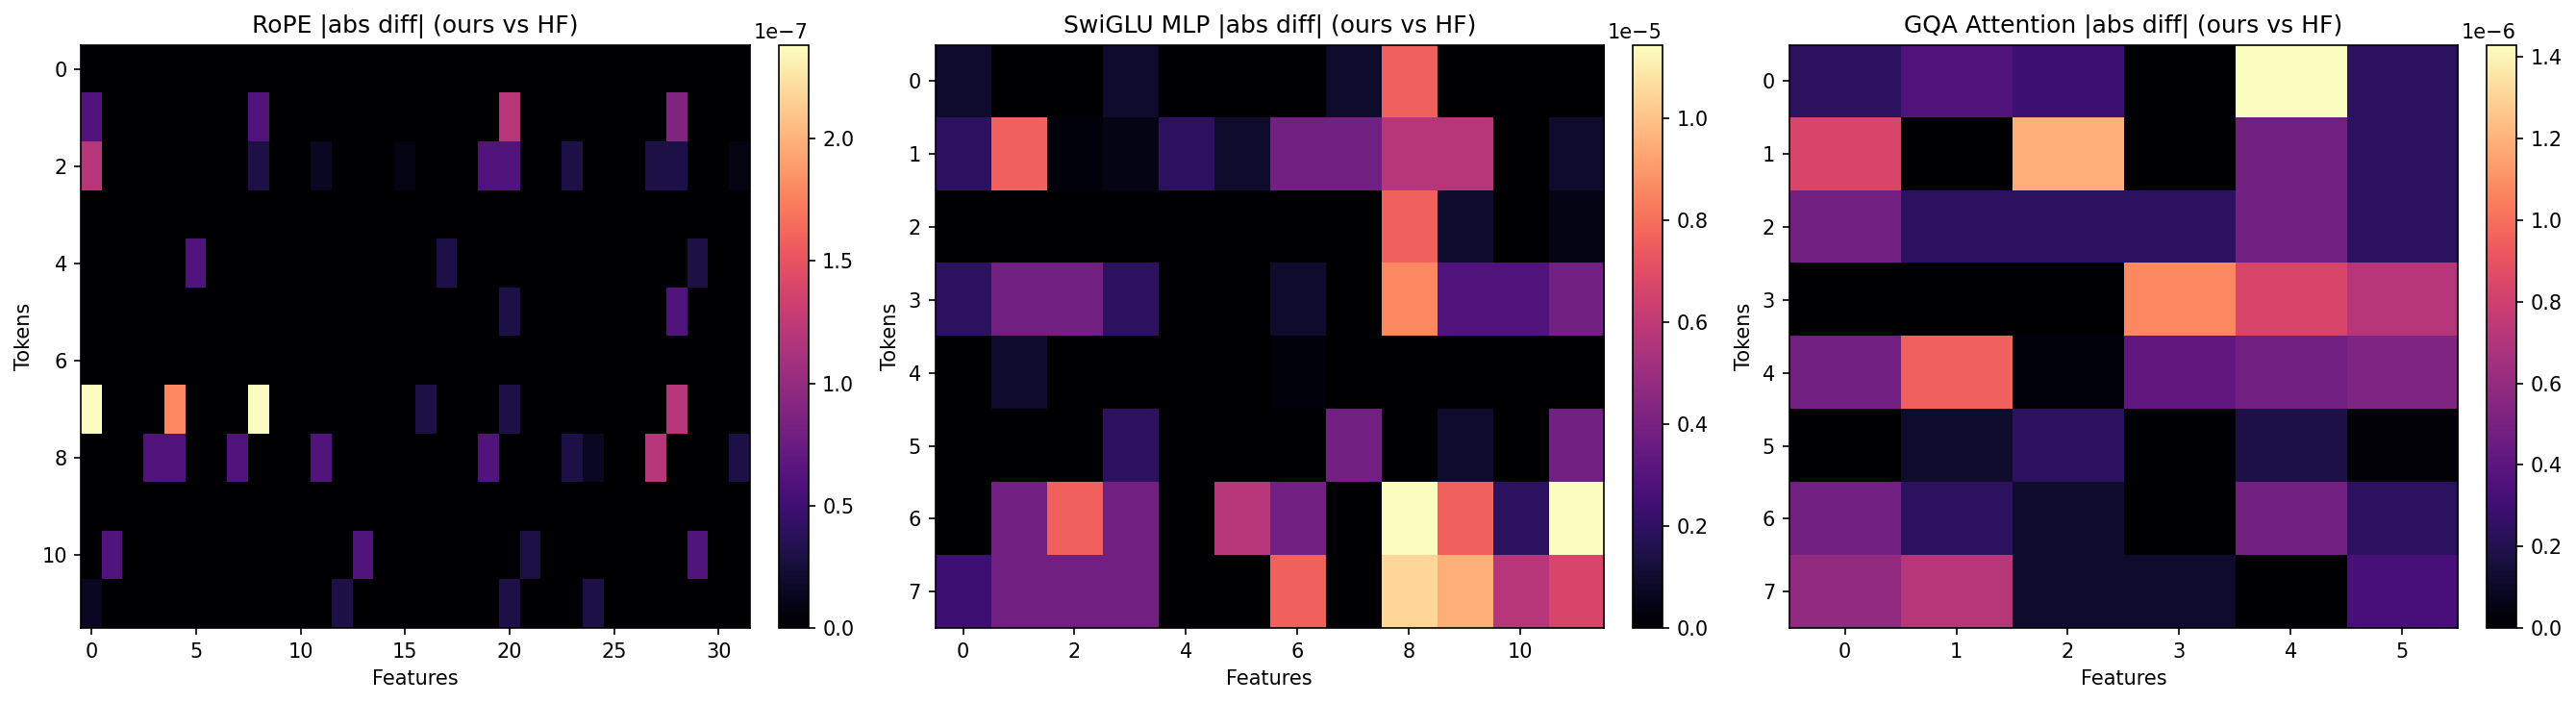

In [17]:
from IPython.display import Image
Image('section6_visualize.png')

### Heatmap results (ours vs Hugging Face)

- **RoPE:** Max abs diff ≈ 2.4e-7. Almost all cells are dark; tiny speckles are within float noise. Rotary rotation and angle pairing look correct.
- **SwiGLU MLP:** Max abs diff ≈ 1.1e-5. Dark overall with a few brighter spots, still within tolerance. Splitting/Swish/gating appear aligned; no structured stripes that would hint at mis-split or wrong activation.
- **GQA Attention:** Max abs diff ≈ 1.4e-6. Mostly dark with small patches; KV repeat and scaling look good. No diagonal/stripe artifacts, so head grouping and RoPE-before-repeat logic are likely correct.

Conclusion: Parity holds to within expected float noise across all three modules. If you tweak code, re-run and watch for new bright patterns or higher max diffs (>1e-5) as a regression signal.


## Summary and future work

We added RMSNorm, RoPE, SwiGLU, and GQA to Needle’s transformer and matched Hugging Face outputs. Tests check numpy baselines, HF parity, and finite values. Heatmaps show parity within ~1e-5.

Future work
- Finetune end-to-end vs. LayerNorm+ReLU+MHA; report loss/accuracy curves.
- Benchmark tokens/s and peak memory on long contexts (CPU/GPU) for different num_kv_heads and sequence lengths.
- Add mixed-precision (bf16/fp16) and very-long-sequence tests to catch RoPE angle or Swish overflow issues.
- Explore fused kernels or small CUDA ops for RMSNorm/SwiGLU; cache RoPE frequencies for long prompts.
- Ship a prompt-to-text demo plus a KV cache/latency table; log seeds/env/test versions. Note common failures (build, dtype) and quick fixes; consider CI to run parity tests. Keep a checklist (env, tests, heatmaps), note acceptable tolerances/drift, and add guidance for packaging a private code link, license, and data sources.